# CE322 Pattern Recognition — TikTok Project
## Notebook 1: Data Preprocessing

This notebook loads the raw dataset, inspects it, handles missing values, removes outliers, and saves a clean version for downstream analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/tiktok_videos.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Shape: (55160, 17)
Columns: ['video_id', 'url', 'author_username', 'author_id', 'author_category', 'description', 'create_time_utc', 'duration_seconds', 'hashtag_count', 'engagement_rate', 'is_weekend', 'digg_count', 'comment_count', 'share_count', 'play_count', 'source_target', 'collected_at_utc']


,video_id,url,author_username,author_id,author_category,description,create_time_utc,duration_seconds,hashtag_count,engagement_rate,is_weekend,digg_count,comment_count,share_count,play_count,source_target,collected_at_utc
0,7630058041693474056,https://www.tiktok.com/@melihagbi/video/763005...,melihagbi,6720681797632771077,entertainment,aristo şaşırttın be - Gün 230/365,2026-04-18T11:22:09+00:00,53.0,0,0.044188,1,1646,12,30,38200,user:melihagbi,2026-04-18T23:19:36.271637+00:00
1,7629760934583536914,https://www.tiktok.com/@melihagbi/video/762976...,melihagbi,6720681797632771077,entertainment,Selanik’te bi Osmanlı kalesi Gün 229/365,2026-04-17T16:09:15+00:00,38.0,0,0.036502,0,2195,20,70,62600,user:melihagbi,2026-04-18T23:19:36.271657+00:00
2,7629283124785990919,https://www.tiktok.com/@melihagbi/video/762928...,melihagbi,6720681797632771077,entertainment,çok üzgünüm,2026-04-16T09:15:05+00:00,19.0,0,0.062140,0,20500,88,229,335000,user:melihagbi,2026-04-18T23:19:36.271667+00:00


## 1.1 Basic Inspection

In [2]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Null Counts ===")
print(df.isnull().sum())
print("\n=== Unique Authors:", df['author_username'].nunique())
print("=== Author Categories:")
print(df['author_category'].value_counts())

=== Data Types ===
video_id              int64
url                  object
author_username      object
author_id             int64
author_category      object
description          object
create_time_utc      object
duration_seconds    float64
hashtag_count         int64
engagement_rate     float64
is_weekend            int64
digg_count            int64
comment_count         int64
share_count           int64
play_count            int64
source_target        object
collected_at_utc     object
dtype: object

=== Null Counts ===
video_id               0
url                    0
author_username        0
author_id              0
author_category        0
description         5701
create_time_utc        0
duration_seconds     135
hashtag_count          0
engagement_rate       28
is_weekend             0
digg_count             0
comment_count          0
share_count            0
play_count             0
source_target          0
collected_at_utc       0
dtype: int64

=== Unique Authors: 214
=== Aut

## 1.2 Outlier Detection & Removal

Engagement rate stats:
count    55132.000000
mean         0.036262
std          0.654951
min          0.000000
25%          0.016000
50%          0.025590
75%          0.040583
max        140.471264
Name: engagement_rate, dtype: float64

Rows with engagement_rate > 1.0: 7
Rows with engagement_rate > 0.5: 9


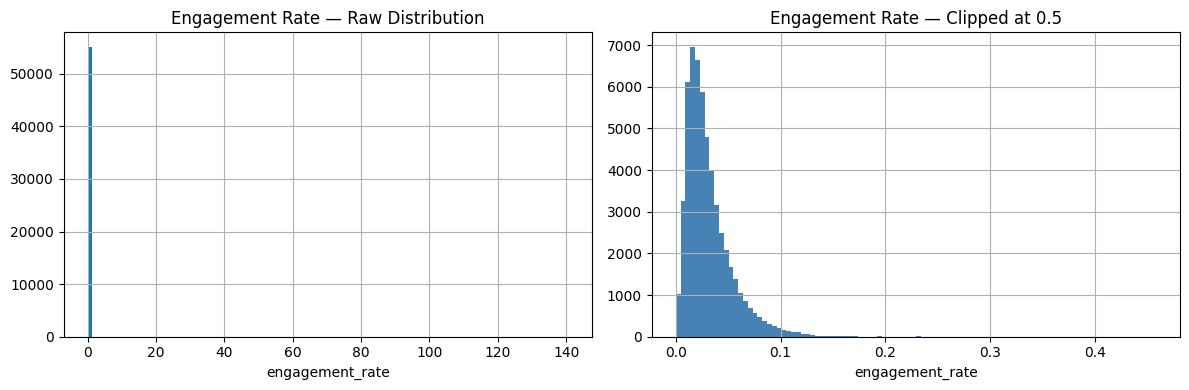

In [3]:
# engagement_rate outlier inspection
print("Engagement rate stats:")
print(df['engagement_rate'].describe())
print(f"\nRows with engagement_rate > 1.0: {(df['engagement_rate'] > 1.0).sum()}")
print(f"Rows with engagement_rate > 0.5: {(df['engagement_rate'] > 0.5).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['engagement_rate'].hist(bins=100, ax=axes[0])
axes[0].set_title('Engagement Rate — Raw Distribution')
axes[0].set_xlabel('engagement_rate')
df[df['engagement_rate'] <= 0.5]['engagement_rate'].hist(bins=100, ax=axes[1], color='steelblue')
axes[1].set_title('Engagement Rate — Clipped at 0.5')
axes[1].set_xlabel('engagement_rate')
plt.tight_layout()
plt.savefig('../data/engagement_dist.png', dpi=150)
plt.show()

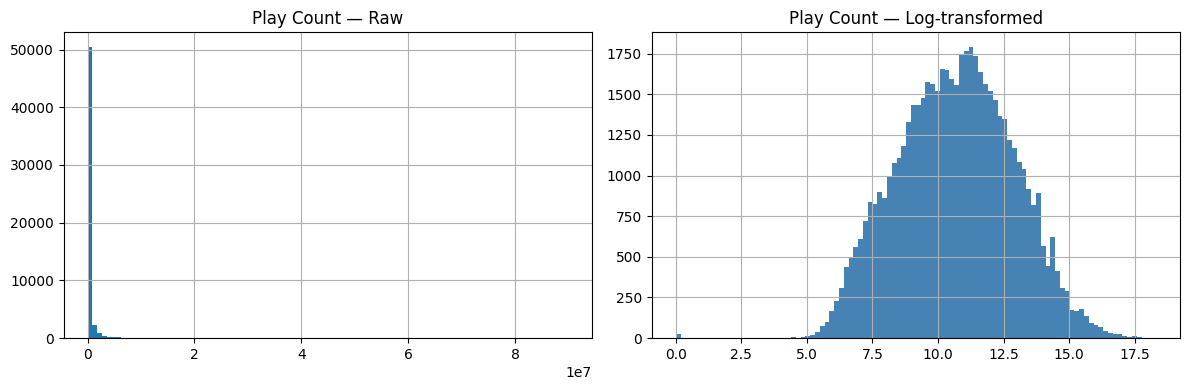

In [4]:
# play_count distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['play_count'].hist(bins=100, ax=axes[0])
axes[0].set_title('Play Count — Raw')
np.log1p(df['play_count']).hist(bins=100, ax=axes[1], color='steelblue')
axes[1].set_title('Play Count — Log-transformed')
plt.tight_layout()
plt.savefig('../data/playcount_dist.png', dpi=150)
plt.show()

## 1.3 Cleaning

In [5]:
# 1. Fill nulls
df['description'] = df['description'].fillna('')
df['duration_seconds'] = df['duration_seconds'].fillna(df['duration_seconds'].median())
df['engagement_rate'] = df['engagement_rate'].fillna(0)

# 2. Clip engagement_rate outliers (99th percentile)
er_cap = df['engagement_rate'].quantile(0.99)
print(f"Capping engagement_rate at 99th percentile: {er_cap:.4f}")
df['engagement_rate'] = df['engagement_rate'].clip(upper=er_cap)

# 3. Drop identifier-only columns (keep source_target as author reference)
df = df.drop(columns=['url', 'author_id'])

# 4. Parse timestamps
df['create_time_utc'] = pd.to_datetime(df['create_time_utc'], utc=True)
df['collected_at_utc'] = pd.to_datetime(df['collected_at_utc'], utc=True)

print(f"\nClean shape: {df.shape}")
print(f"Remaining nulls:\n{df.isnull().sum()}")
df.head(3)

Capping engagement_rate at 99th percentile: 0.1136

Clean shape: (55160, 15)
Remaining nulls:
video_id            0
author_username     0
author_category     0
description         0
create_time_utc     0
duration_seconds    0
hashtag_count       0
engagement_rate     0
is_weekend          0
digg_count          0
comment_count       0
share_count         0
play_count          0
source_target       0
collected_at_utc    0
dtype: int64


,video_id,author_username,author_category,description,create_time_utc,duration_seconds,hashtag_count,engagement_rate,is_weekend,digg_count,comment_count,share_count,play_count,source_target,collected_at_utc
0,7630058041693474056,melihagbi,entertainment,aristo şaşırttın be - Gün 230/365,2026-04-18 11:22:09+00:00,53.0,0,0.044188,1,1646,12,30,38200,user:melihagbi,2026-04-18 23:19:36.271637+00:00
1,7629760934583536914,melihagbi,entertainment,Selanik’te bi Osmanlı kalesi Gün 229/365,2026-04-17 16:09:15+00:00,38.0,0,0.036502,0,2195,20,70,62600,user:melihagbi,2026-04-18 23:19:36.271657+00:00
2,7629283124785990919,melihagbi,entertainment,çok üzgünüm,2026-04-16 09:15:05+00:00,19.0,0,0.062140,0,20500,88,229,335000,user:melihagbi,2026-04-18 23:19:36.271667+00:00


In [6]:
# Save clean dataset
df.to_csv('../data/tiktok_clean.csv', index=False)
print("Saved: data/tiktok_clean.csv")

Saved: data/tiktok_clean.csv
